Script to develop evaluation procedure

In [3]:
from span_marker import SpanMarkerModel
from transformers import AutoConfig

import argparse
import json
import torch
import re
import os
from pathlib import Path
from datasets import load_dataset
from transformers import TrainingArguments

from dataset_processing import hf_dataset_to_gliner_format, CLIRENER_LABELS_V1, transform_to_ner_format

In [4]:
def ids_to_labels(pred_id_seqs, label_list):
    """
    Convert sequences of prediction IDs into label sequences.

    Args:
        pred_id_seqs (list[list[int]]): e.g. model predictions [[2, 5, 0], ...]
        label_list (list[str]): label names from dataset, e.g. dataset["train"].features["ner_tags"].feature.names

    Returns:
        list[list[str]]: converted label sequences
    """
    return [[label_list[i] for i in seq] for seq in pred_id_seqs]

In [5]:
dataset = load_dataset("P0L3/CliReNER_v_1_1_28_SILVER")
labels = dataset["train"].features["ner_tags"].feature.names

TRUE = dataset["test"]["ner_tags"]

In [6]:
model_path_or_id = "models/P0L3/span-marker-P0L3/clirebert_clirevocab_uncased-CliReNER_v_0_0_26/checkpoint-final"
model = SpanMarkerModel.from_pretrained(model_path_or_id)


In [7]:
import transformers
print(transformers.__version__)

4.50.0


In [8]:
text =  [row["text"] for row in dataset["test"]]

entities_list = model.predict(text)

SpanMarker model predictions are being computed on the CPU while CUDA is available. Moving the model to CUDA using `model.cuda()` before performing predictions is heavily recommended to significantly boost prediction speeds.


In [10]:
labels

['O',
 'B-Asset',
 'I-Asset',
 'B-Body Part',
 'I-Body Part',
 'B-Body of Water',
 'I-Body of Water',
 'B-Chemical',
 'I-Chemical',
 'B-Disease',
 'I-Disease',
 'B-Ecosystem',
 'I-Ecosystem',
 'B-Energy Source',
 'I-Energy Source',
 'B-Field of Study',
 'I-Field of Study',
 'B-Geographical Feature',
 'I-Geographical Feature',
 'B-Intellectual Artefact',
 'I-Intellectual Artefact',
 'B-Location',
 'I-Location',
 'B-Mathematical Expression',
 'I-Mathematical Expression',
 'B-Measuring Device',
 'I-Measuring Device',
 'B-Meteorological Phenomenon',
 'I-Meteorological Phenomenon',
 'B-Method',
 'I-Method',
 'B-Natural Disaster',
 'I-Natural Disaster',
 'B-Natural Phenomenon',
 'I-Natural Phenomenon',
 'B-Organism',
 'I-Organism',
 'B-Organization',
 'I-Organization',
 'B-Other',
 'I-Other',
 'B-Person',
 'I-Person',
 'B-Physical Artefact',
 'I-Physical Artefact',
 'B-Physical Phenomenon',
 'I-Physical Phenomenon',
 'B-Policy',
 'I-Policy',
 'B-Quantity',
 'I-Quantity',
 'B-Satellite',
 'I-

In [11]:
model_predictions = []
for i, row in enumerate(entities_list):
    row_text = text[i]
    # print(row)
    entities = []
    for entity in row:
        temp_dict = {
            'start': entity["char_start_index"],
            'end': entity["char_end_index"],
            'text': entity["span"],
            'label': entity["label"],
            'score': entity["score"]
        }
        entities.append(temp_dict)
        
    prediction = {
        "text": row_text,
        "entities": entities
    }
    
    model_predictions.append(prediction)
labels = list(CLIRENER_LABELS_V1)
model_predictions_transformed = transform_to_ner_format(model_predictions, labels)

model_predictions_ids = []
for row in model_predictions_transformed[0]:
    model_predictions_ids.append(row["ner_tags"])

In [12]:
from nervaluate import Evaluator

labels = dataset["train"].features["ner_tags"].feature.names
true = ids_to_labels(TRUE, labels)
  
pred = ids_to_labels(model_predictions_ids, labels)
   
evaluator = Evaluator(true, pred, tags=list(CLIRENER_LABELS_V1), loader="list")

In [22]:
suma = 0
for row in TRUE:
    for ajdi in row:
        if ajdi == 3:
            suma += 1
            
print(suma)

5


In [13]:
results, results_by_tag, result_indices, result_indices_by_tag = evaluator.evaluate()

import pandas as pd

df = pd.DataFrame(results)
print(df)

print("\n##results##:\n")
print("Strict: ", results["strict"])
print("Exact:  ", results["exact"])
print("\##results_by_tag##:\n")
print(results_by_tag)
print("\##result_indices##:\n")
print(result_indices)
print("\##result_indices_by_tag##:\n")
print(result_indices_by_tag)

             ent_type     partial      strict       exact
correct    661.000000  684.000000  633.000000  684.000000
incorrect   71.000000    0.000000   99.000000   48.000000
partial      0.000000   48.000000    0.000000    0.000000
missed      68.000000   68.000000   68.000000   68.000000
spurious    21.000000   21.000000   21.000000   21.000000
possible   800.000000  800.000000  800.000000  800.000000
actual     753.000000  753.000000  753.000000  753.000000
precision    0.877822    0.940239    0.840637    0.908367
recall       0.826250    0.885000    0.791250    0.855000
f1           0.851256    0.911784    0.815196    0.880876

##results##:

Strict:  {'correct': 633, 'incorrect': 99, 'partial': 0, 'missed': 68, 'spurious': 21, 'possible': 800, 'actual': 753, 'precision': 0.8406374501992032, 'recall': 0.79125, 'f1': 0.8151963940759821}
Exact:   {'correct': 684, 'incorrect': 48, 'partial': 0, 'missed': 68, 'spurious': 21, 'possible': 800, 'actual': 753, 'precision': 0.9083665338645418

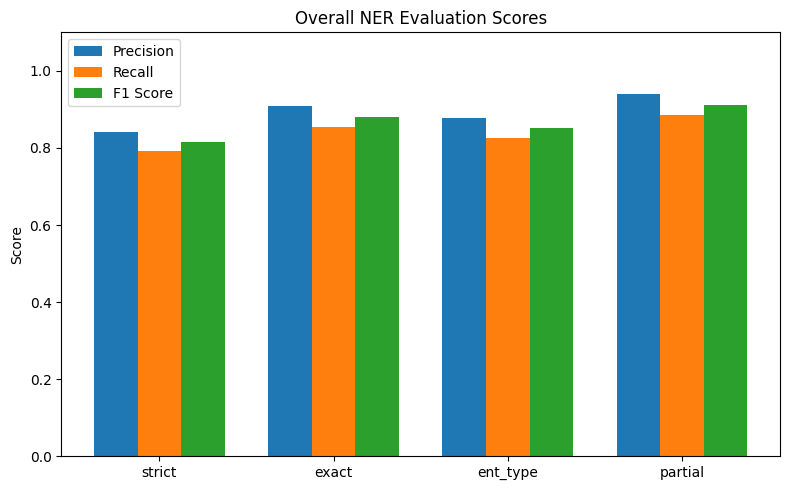

In [50]:
import matplotlib.pyplot as plt

def plot_overall_metrics(results):
    metrics = ['strict', 'exact', 'ent_type', 'partial']
    precision = [results[m]['precision'] for m in metrics]
    recall = [results[m]['recall'] for m in metrics]
    f1 = [results[m]['f1'] for m in metrics]

    x = range(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width for i in x], precision, width, label='Precision')
    ax.bar(x, recall, width, label='Recall')
    ax.bar([i + width for i in x], f1, width, label='F1 Score')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Overall NER Evaluation Scores")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_overall_metrics(results)